In [ ]:
pip install language-tool-python

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.5/55.5 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.6/55.6 kB 3.2 MB/s eta 0:00:00


In [ ]:
!pip install spacy
!python -m spacy download en_core_web_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 74.6 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [ ]:
import pandas as pd
import spacy
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv('Final_df.csv')

In [ ]:
df.head()

,Question,Response_Number,Response,Score,Answer
0,What is data science?,R1,Data science is a field that combines statisti...,1.00,Data science is an interdisciplinary field tha...
1,What are the key steps in the data science pro...,R1,The key steps in the data science process incl...,0.95,The key steps typically include problem defini...
2,What is the difference between supervised and ...,R1,Supervised learning uses labeled data to train...,1.00,Supervised learning involves training a model ...
3,Explain the bias-variance tradeoff.,R1,The bias-variance tradeoff is a concept in mac...,1.00,The bias-variance tradeoff is the balance betw...
4,What is feature engineering?,R1,Feature engineering is the process of creating...,1.00,Feature engineering is the process of selectin...


In [ ]:
df = df[['Question','Answer','Response','Score']]

In [ ]:
df.head()

,Question,Answer,Response,Score
0,What is data science?,Data science is an interdisciplinary field tha...,Data science is a field that combines statisti...,1.00
1,What are the key steps in the data science pro...,The key steps typically include problem defini...,The key steps in the data science process incl...,0.95
2,What is the difference between supervised and ...,Supervised learning involves training a model ...,Supervised learning uses labeled data to train...,1.00
3,Explain the bias-variance tradeoff.,The bias-variance tradeoff is the balance betw...,The bias-variance tradeoff is a concept in mac...,1.00
4,What is feature engineering?,Feature engineering is the process of selectin...,Feature engineering is the process of creating...,1.00


In [ ]:
# Load spaCy English model
nlp = spacy.load("en_core_web_sm")

In [ ]:
def grammar_quality_score(text):
    if not isinstance(text, str) or text.strip() == "":
        return 0.0

    doc = nlp(text)
    issues = 0
    word_count = len(text.split())

    # Passive voice
    issues += sum(1 for token in doc if token.dep_ == "auxpass")


    # Missing subject/verb
    if not any(tok.dep_ == "nsubj" for tok in doc):
        issues += 1
    if not any(tok.pos_ == "VERB" for tok in doc):
        issues += 1

    # Missing end punctuation
    if not text.strip().endswith(('.', '?', '!')):
        issues += 1

    # Normalize the score: lower issues → higher score
    max_acceptable_issues = max(1, word_count // 20)
    penalty_ratio = min(1.0, issues / (max_acceptable_issues + 1e-5))  # to avoid division by zero

    score = 1.0 - penalty_ratio  # Score between 0 and 1
    return round(max(0.2, min(1.0, score)), 3)

In [ ]:
grammar_score = df['Response'].apply(grammar_quality_score)

In [ ]:
grammar_score

,Response
0,0.5
1,1.0
2,1.0
3,1.0
4,1.0
...,...
2615,0.2
2616,1.0
2617,1.0
2618,1.0


In [ ]:
grammar_score.to_csv('grammar_quality_score.csv')

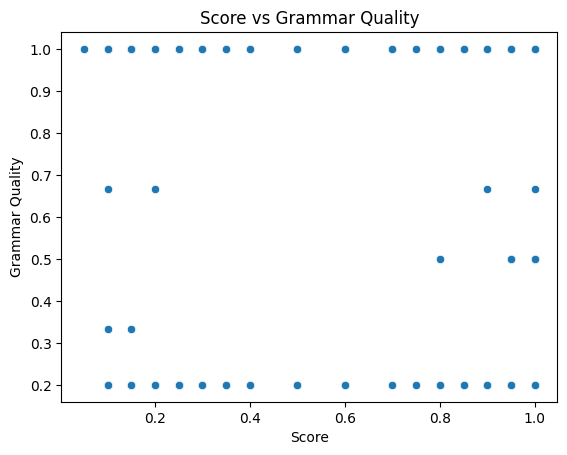

In [ ]:
sns.scatterplot(x=df['Score'], y=grammar_score)
plt.title('Score vs Grammar Quality')
plt.xlabel('Score')
plt.ylabel('Grammar Quality')
plt.show()